## Setting Up the **Environment**

In [ ]:
#Set seeds for reproducibity
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
#Importing Dependencies
import os
import json
from zipfile import ZipFile
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers,models

In [ ]:
!pip install kaggle

In [ ]:
kaggle_credentails=json.load(open('/content/kaggle.json'))

In [ ]:
#setup the environment using kaggle API key
os.environ['KAGGLE_USERNAME']=kaggle_credentails['username']
os.environ['KAGGLE_KEY']=kaggle_credentails['key']

In [ ]:
#Downloading the dataset
!kaggle datasets download -d warcoder/soyabean-seeds


Dataset URL: https://www.kaggle.com/datasets/warcoder/soyabean-seeds
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/86.1M [00:00<?, ?B/s]
100% 86.1M/86.1M [00:00<00:00, 1.41GB/s]


In [ ]:
#Unzip the downloaded dataset
with ZipFile('/content/soyabean-seeds.zip','r') as zip:
  zip.extractall()

In [ ]:
#printing the path and labels
print(os.listdir("Soybean Seeds"))


print(len(os.listdir("Soybean Seeds/Broken soybeans")))
print(os.listdir("Soybean Seeds/Broken soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Immature soybeans")))
print(os.listdir("Soybean Seeds/Immature soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Intact soybeans")))
print(os.listdir("Soybean Seeds/Intact soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Skin-damaged soybeans")))
print(os.listdir("Soybean Seeds/Skin-damaged soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Spotted soybeans")))
print(os.listdir("Soybean Seeds/Spotted soybeans")[:5])



['Spotted soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Intact soybeans', 'Broken soybeans']
1002
['561.jpg', '704.jpg', '418.jpg', '908.jpg', '775.jpg']
1125
['561.jpg', '704.jpg', '1082.jpg', '418.jpg', '908.jpg']
1201
['561.jpg', '704.jpg', '1082.jpg', '418.jpg', '908.jpg']
1127
['561.jpg', '704.jpg', '1082.jpg', '418.jpg', '908.jpg']
1058
['561.jpg', '704.jpg', '418.jpg', '908.jpg', '775.jpg']


## Data **Visualization**

In [ ]:
#Dataset path
Dataset_path="/content/Soybean Seeds"

(227, 227, 3)


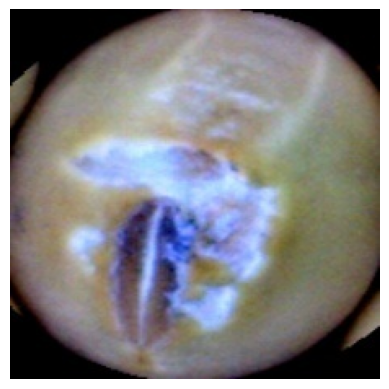

In [ ]:
#Displaying an image using matplotlib and numpy array
image_path="/content/Soybean Seeds/Immature soybeans/1010.jpg"
image=mpimg.imread(image_path)
print(image.shape)
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
print(image[0:5, 0:5, :]) #First 5*5 pixels

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


In [ ]:
#pixel values of center
h, w, _ = image.shape
center_crop = image[h//2 - 2:h//2 + 3, w//2 - 2:w//2 + 3, :]
print(center_crop)


[[[170 206 255]
  [176 211 253]
  [180 214 252]
  [183 215 255]
  [187 216 255]]

 [[163 205 255]
  [170 207 252]
  [177 210 251]
  [181 213 252]
  [183 212 252]]

 [[158 201 252]
  [166 204 253]
  [174 208 253]
  [179 212 253]
  [181 213 251]]

 [[155 194 251]
  [162 199 252]
  [168 206 253]
  [175 212 255]
  [181 216 254]]

 [[162 197 255]
  [164 201 254]
  [170 208 255]
  [177 214 255]
  [182 217 255]]]


In [ ]:
#Get class names and counts
classes = os.listdir(Dataset_path)
class_counts = [len(os.listdir(os.path.join(Dataset_path, cls))) for cls in classes]
print(classes)
print(class_counts)


['Spotted soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Intact soybeans', 'Broken soybeans']
[1058, 1125, 1127, 1201, 1002]


### Exploratory Data **Analysis**

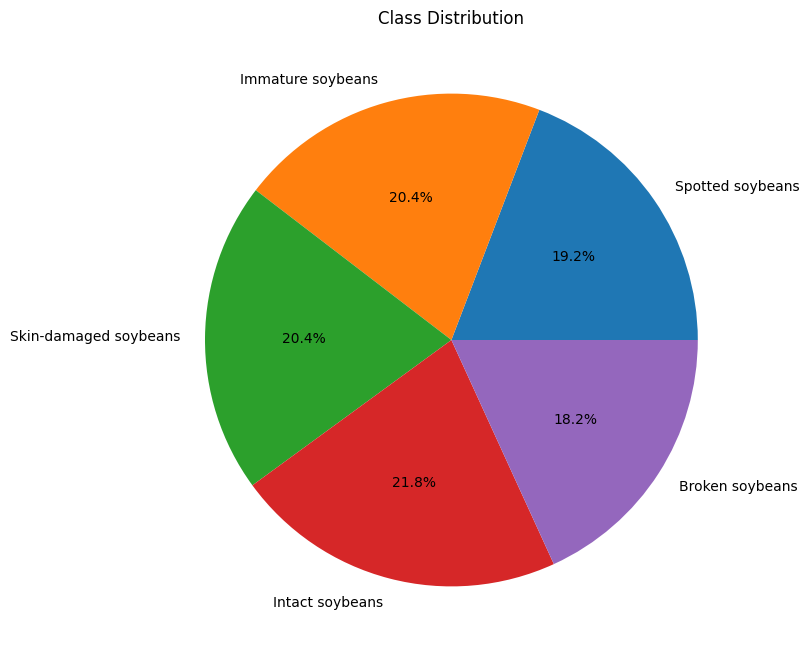

In [ ]:
#pie chart see class distribution
plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=classes, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.show()

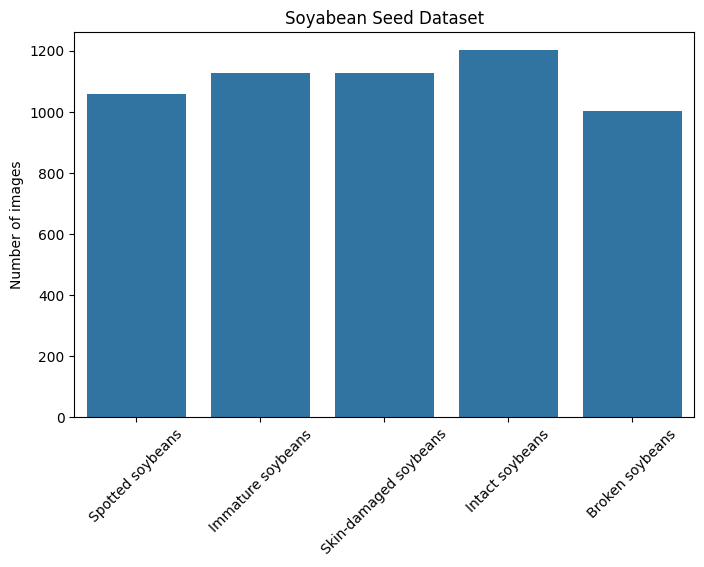

In [ ]:
#Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=class_counts)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of images')
plt.title("Soyabean Seed Dataset")
plt.show()

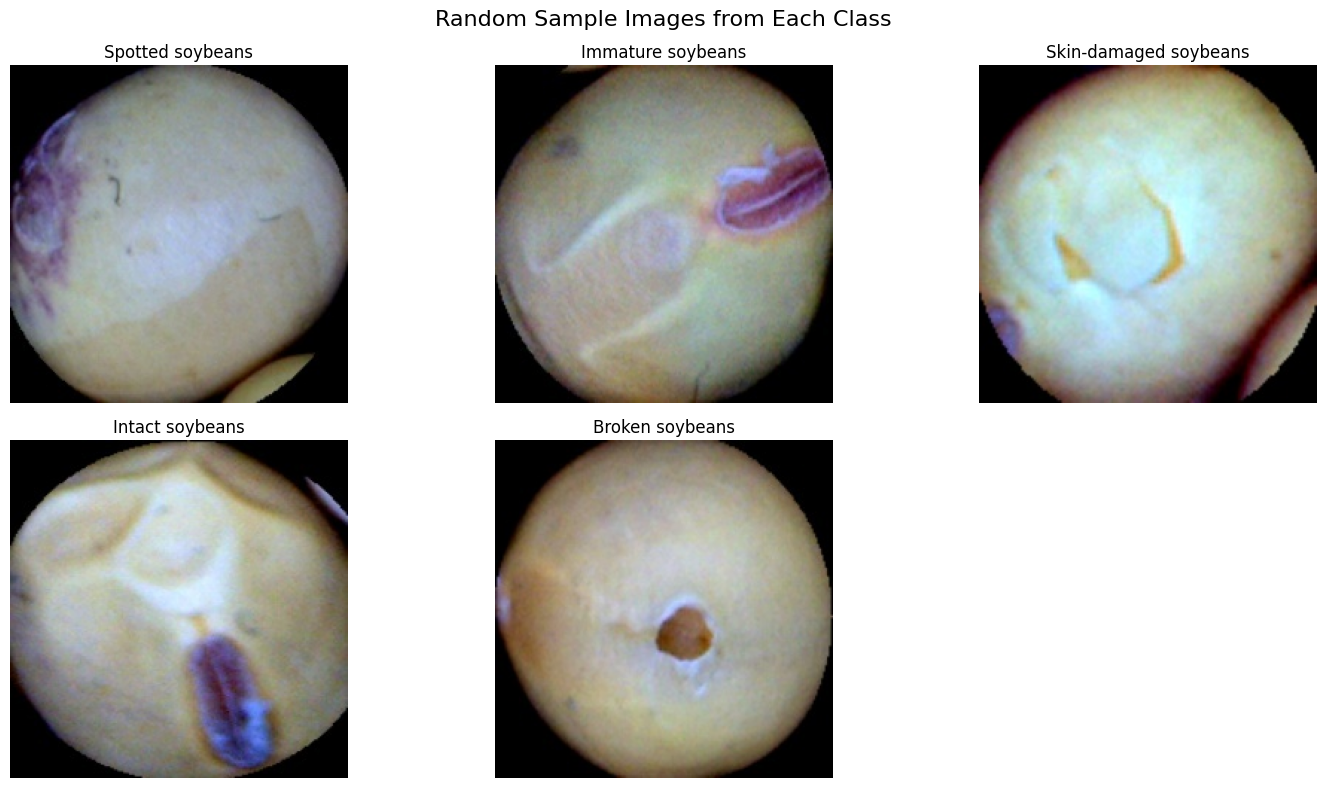

In [ ]:
#Some random sample images
plt.figure(figsize=(15,8))
for idx, cls in enumerate(classes, start=1):
    img_path = os.path.join(Dataset_path, cls, random.choice(os.listdir(os.path.join(Dataset_path, cls))))
    plt.subplot(2, (len(classes) + 1) // 2, idx)
    plt.imshow(mpimg.imread(img_path))
    plt.title(cls)
    plt.axis('off')

plt.suptitle("Random Sample Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()


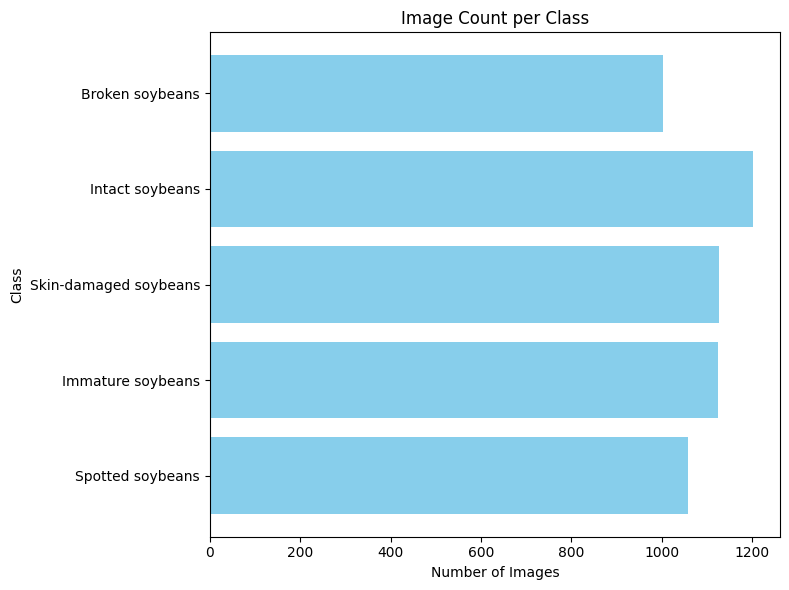

In [ ]:
# Horizontal Bar Graph for image count per class
per_class_counts = {cls: len(os.listdir(os.path.join(Dataset_path, cls))) for cls in classes}

plt.figure(figsize=(8, 6))
plt.barh(list(per_class_counts.keys()), list(per_class_counts.values()), color='skyblue')
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()


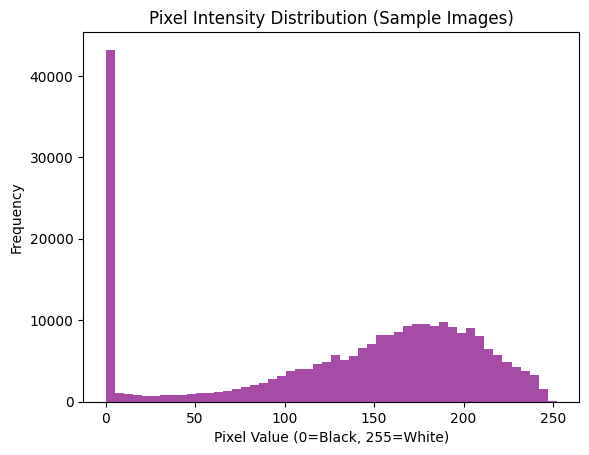

In [ ]:
import cv2
sample_images = []
for cls in classes:
    img_path = os.path.join(Dataset_path, cls, random.choice(os.listdir(os.path.join(Dataset_path, cls))))
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # convert to grayscale
    sample_images.append(img.flatten())

all_pixels = np.concatenate(sample_images)
plt.hist(all_pixels, bins=50, color='purple', alpha=0.7)
plt.title("Pixel Intensity Distribution (Sample Images)")
plt.xlabel("Pixel Value (0=Black, 255=White)")
plt.ylabel("Frequency")
plt.show()


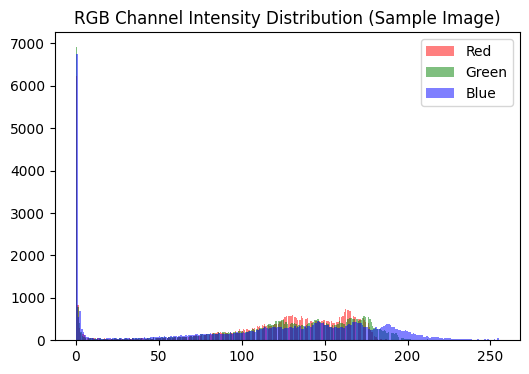

In [ ]:
sample_img = mpimg.imread(os.path.join(Dataset_path, classes[0], random.choice(os.listdir(os.path.join(Dataset_path, classes[0])))))
plt.figure(figsize=(6, 4))
plt.hist(sample_img[:,:,0].ravel(), bins=256, color='red', alpha=0.5, label='Red')
plt.hist(sample_img[:,:,1].ravel(), bins=256, color='green', alpha=0.5, label='Green')
plt.hist(sample_img[:,:,2].ravel(), bins=256, color='blue', alpha=0.5, label='Blue')
plt.legend()
plt.title("RGB Channel Intensity Distribution (Sample Image)")
plt.show()


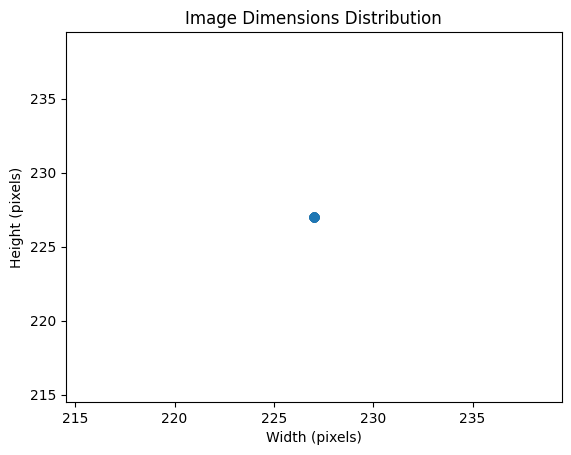

In [ ]:
widths, heights = [], []
for cls in classes:
    for img_name in os.listdir(os.path.join(Dataset_path, cls))[:20]:  # limit to speed up
        img_path = os.path.join(Dataset_path, cls, img_name)
        img = mpimg.imread(img_path)
        heights.append(img.shape[0])
        widths.append(img.shape[1])

plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Dimensions Distribution")
plt.show()

